In [4]:
import joblib
import pandas as pd
import shap
import os

pipeline = joblib.load("../models/churn_pipeline.pkl")
df = pd.read_csv("../data/telco_churn.csv")


C:\Users\Afshaan\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Afshaan\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Afshaan\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.6.1. This might lead to breaking 

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df.drop("customerID", axis=1, inplace=True)
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

X = df.drop("Churn", axis=1)
y = df["Churn"]


In [6]:
preprocessor = pipeline.named_steps["preprocessing"]
model = pipeline.named_steps["model"]

X_transformed = preprocessor.transform(X)


In [7]:
explainer = shap.LinearExplainer(model, X_transformed)
shap_values = explainer(X_transformed)


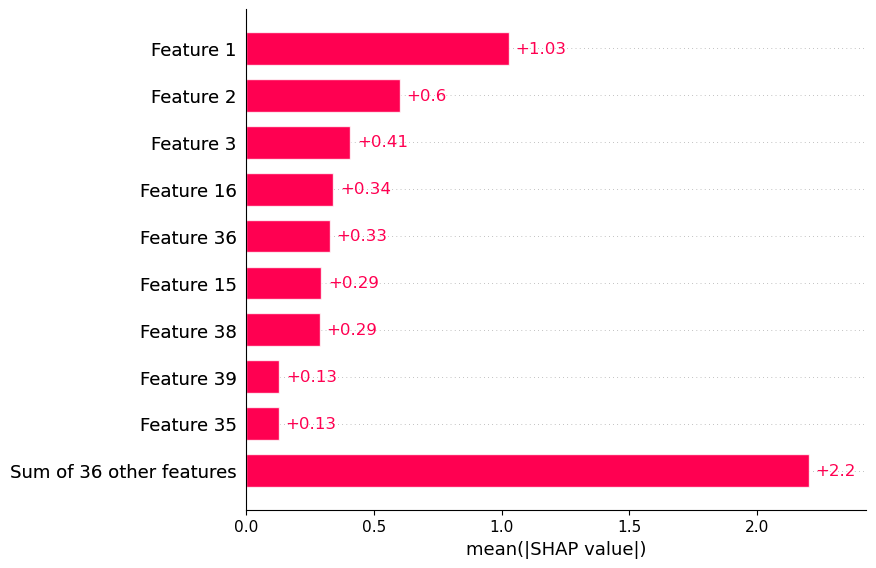

In [8]:
shap.plots.bar(shap_values)


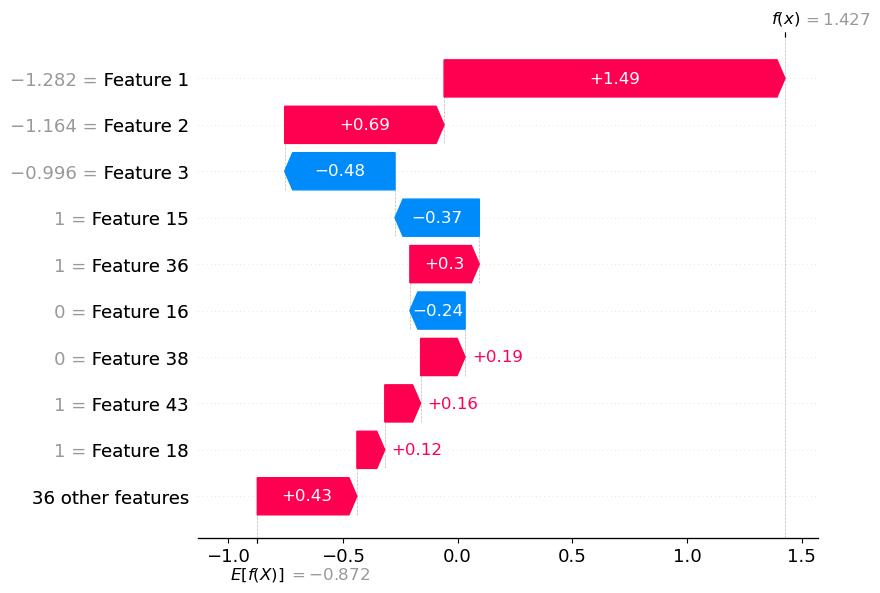

In [9]:
shap.plots.waterfall(shap_values[0])


In [12]:
feature_names = preprocessor.get_feature_names_out()

explainer = shap.Explainer(model, X_transformed, feature_names=feature_names)
shap_values = explainer(X_transformed)


In [13]:
feature_names = [name.replace("cat__", "").replace("num__", "") 
                 for name in feature_names]
